# Syndrome Lookup Tables for QEC Codes

Quantum error correction (QEC) protects a *logical* qubit against hardware noise by spreading its information across many *physical* qubits. Instead of directly measuring (and collapsing) the logical qubit, we periodically measure a set of carefully chosen parity checks — called **stabilizers** — on extra *ancilla* qubits. The measurement outcomes form a bit string called the **syndrome**.

Crucially, the syndrome tells us *something happened* without revealing the encoded information. A classical decoder then maps the observed syndrome to the most likely error, which we undo with a corresponding recovery operation.

In this notebook we build that classical decoder in its simplest form: a **lookup table** `syndrome → recovery` obtained by enumerating errors and computing their syndromes. Part 1 (below) treats the repetition code; later parts will extend the same pattern to the surface code.

## Part 1: Repetition Code

The `n`-qubit **repetition code** protects against single-qubit bit-flip (X) errors by encoding one logical qubit into `n` identical physical copies:

$$|0\rangle_L = |00\dots0\rangle,\qquad |1\rangle_L = |11\dots1\rangle.$$

Since the two logical states differ in every qubit, comparing neighboring qubits reveals whether something flipped. We add `m = n-1` ancilla qubits; ancilla `a_i` measures the parity $Z_iZ_{i+1}$ of data qubits `d_i` and `d_{i+1}`. If the two data qubits still agree, `a_i = 0`; if exactly one was flipped, `a_i = 1`. These `m` parity checks are the **stabilizer generators** of the code, and their outcomes form the length-`m` syndrome.

Because each ancilla touches only two neighboring data qubits, the code has a very visual structure: a 1-D chain.

### Tool 1: For visualize the code

n is the number of data qubits, and the number of ancilla qubits would be m=n-1.

The drawing convention used below:

- **Blue circles** (`d0, d1, …, d_{n-1}`) are data qubits — the physical qubits that hold the encoded logical state.
- **Red circles** (`a0, a1, …, a_{n-2}`) are ancilla qubits — extra qubits used only to measure the stabilizers.
- **Gray lines** connect each ancilla to the two data qubits it measures. In other words, each line indicates a CNOT in the syndrome extraction circuit (data qubit as control, ancilla as target). Ancilla `a_i` has two incident lines going to `d_i` and `d_{i+1}`, so measuring `a_i` reveals the parity $Z_iZ_{i+1}$. These lines are the analog of the "edges" in a Tanner graph of the code.

`radius` and `line_width` are exposed so you can rescale the figure for larger `n` or denser codes later on.

In [16]:
import matplotlib.pyplot as plt
from matplotlib.patches import Circle

def visualize_repetition_code(n, radius=0.25, line_width=1.5):
    fig, ax = plt.subplots(figsize=(1.4 * n, 2.8))
    data_pos = [(i, 0) for i in range(n)]
    anc_pos = [(i + 0.5, 1) for i in range(n - 1)]
    # edges first so circles sit on top
    for i, (x, y) in enumerate(anc_pos):
        ax.plot([data_pos[i][0], x], [0, y], color="gray", linewidth=line_width, zorder=1)
        ax.plot([data_pos[i + 1][0], x], [0, y], color="gray", linewidth=line_width, zorder=1)
    for i, (x, y) in enumerate(data_pos):
        ax.add_patch(Circle((x, y), radius, facecolor="#1f77b4", edgecolor="black", linewidth=line_width, zorder=2))
        ax.text(x, y, f"d{i}", ha="center", va="center", color="white", fontsize=10, zorder=3)
    for i, (x, y) in enumerate(anc_pos):
        ax.add_patch(Circle((x, y), radius, facecolor="#d62728", edgecolor="black", linewidth=line_width, zorder=2))
        ax.text(x, y, f"a{i}", ha="center", va="center", color="white", fontsize=10, zorder=3)
    ax.set_xlim(-0.7, n - 0.3); ax.set_ylim(-0.6, 1.6)
    ax.set_aspect("equal"); ax.axis("off")
    plt.show()

### Tool 2: Print the stabilizer generators

The repetition code that protects against bit-flip (X) errors is stabilized by **Z-type** operators of the form $S_i = Z_iZ_{i+1}$ for $i = 0, 1, \dots, n-2$. There are exactly `m = n-1` generators, matching the `m` ancilla qubits. Each generator commutes with the logical operators $\bar{Z} = Z_0$ and $\bar{X} = X_0 X_1 \cdots X_{n-1}$.

Z-type stabilizers anti-commute with X errors, so measuring them detects **X (bit-flip) errors** — this is why our lookup maps a *Z* syndrome to a set of *X* error patterns.

In [17]:
def stabilizer_generators(n):
    gens = []
    for i in range(n - 1):
        g = ["I"] * n
        g[i] = g[i + 1] = "Z"
        gens.append("".join(g))
    return gens

def print_stabilizer_generators(n):
    for i, g in enumerate(stabilizer_generators(n)):
        print(f"S{i} = {g}")

### Tool 3: Build the lookup table ($2^m$ entries)

Enumerate all $2^n$ X-error patterns and group them by their syndrome. The lookup table has syndrome as keys, with value being the **full list** of X-error patterns consistent with that syndrome, sorted by Hamming weight (lowest first).

A few things worth understanding about this table:

1. **Why $2^m$ entries?** The syndrome is an `m`-bit string with `m = n-1`, so exactly $2^m$ distinct syndromes are possible. A complete decoder must specify a recovery for every one of them. (The trivial all-zeros syndrome corresponds to the empty error *and* the all-flip error, which is the logical X.)

2. **Why do multiple errors share a syndrome?** The code has $2^n$ possible X-error patterns but only $2^m = 2^{n-1}$ syndromes, so *exactly two* distinct X-error patterns produce each syndrome. They always differ by the logical operator `L = X⊗X⊗…⊗X`: if `E` gives syndrome `s`, then `E ⊕ L` gives the same `s` because `L` commutes with every stabilizer. The decoder cannot distinguish these two from the syndrome alone — that is precisely why the code has a finite error-correction threshold.

3. **Minimum-weight decoding.** In practice a decoder needs to *pick one* recovery. Assuming each physical qubit has an independent small flip probability, the most likely error is the one with the **fewest** flips — the first entry in each sorted list. Correct recovery is guaranteed for any error of weight $\le \lfloor (n-1)/2 \rfloor$; beyond that, the decoder may pick the wrong coset representative, causing a logical error.

In [18]:
from itertools import combinations

def syndrome_of(n, error):
    e = [0] * n
    for q in error:
        e[q] ^= 1
    return tuple(e[i] ^ e[i + 1] for i in range(n - 1))

def build_lookup_table(n):
    lookup = {}
    for w in range(n + 1):
        for err in combinations(range(n), w):
            lookup.setdefault(syndrome_of(n, err), []).append(err)
    return lookup

### example 1: n=2

There are $2^1 = 2$ syndromes and 4 error patterns. Syndrome `(0,)` is produced by both `()` and `(0, 1)` (no flip or both flipped); syndrome `(1,)` is produced by both `(0,)` and `(1,)` (flip the first or the second qubit). Seeing both options makes the ambiguity explicit.

When you read the printed table, each syndrome now lists **all** error patterns consistent with it (sorted by weight). 

For $n=2$, it is a error **detection** code, because for the nontrivial syndrome, the two error patterns have the same weight, and hence we can't determine which recovery to correct the error.

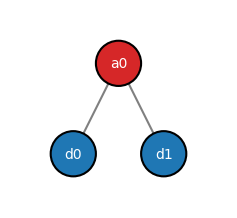

Z-type stabilizer generators (1):
S0 = ZZ

number of entries: 2 (= 2^1)
Z syndrome (0,) -> X errors [(), (0, 1)]
Z syndrome (1,) -> X errors [(0,), (1,)]


In [22]:
n = 2  # number of data qubits
m = n - 1  # number of ancilla qubits
visualize_repetition_code(n)

print(f"Z-type stabilizer generators ({m}):")
print_stabilizer_generators(n)
print()

lookup = build_lookup_table(n)
print(f"number of entries: {len(lookup)} (= 2^{m})")
for s, e in sorted(lookup.items()):
    print(f"Z syndrome {s} -> X errors {e}")

### example 2: n=3

**Worked example (`n = 3`, syndrome `(0, 1)`).** The two listed errors are `(2,)` and `(0, 1)`. These are X on qubit 2 versus X on qubits 0 and 1 — i.e. `IIX` vs `XXI`. Their product is `IIX · XXI = XXX`, which is the **logical X operator** $\bar X$. So the two errors give the *same* syndrome but would flip the logical qubit *differently*:
   - If the true error is `(2,)` (weight 1) and the decoder applies `X_2`, we undo it exactly → no logical error.
   - If the true error is `(0, 1)` (weight 2) and the decoder still applies `X_2`, the net operation is `X_0 X_1 X_2 = \bar X` → the logical qubit is *flipped* (a logical error).

   The decoder cannot tell these two cases apart from the syndrome alone; it picks the most likely one (weight 1). This is why the `n = 3` repetition code corrects only weight-1 errors: once two qubits flip, the guess becomes wrong.


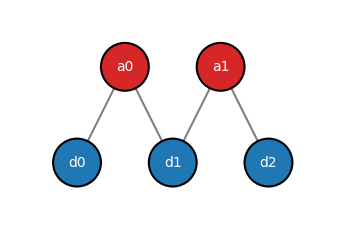

Z-type stabilizer generators (2):
S0 = ZZI
S1 = IZZ

number of entries: 4 (= 2^2)
Z syndrome (0, 0) -> X errors [(), (0, 1, 2)]
Z syndrome (0, 1) -> X errors [(2,), (0, 1)]
Z syndrome (1, 0) -> X errors [(0,), (1, 2)]
Z syndrome (1, 1) -> X errors [(1,), (0, 2)]


In [23]:
n = 3  # number of data qubits
m = n - 1  # number of ancilla qubits
visualize_repetition_code(n)

print(f"Z-type stabilizer generators ({m}):")
print_stabilizer_generators(n)
print()

lookup = build_lookup_table(n)
print(f"number of entries: {len(lookup)} (= 2^{m})")
for s, e in sorted(lookup.items()):
    print(f"Z syndrome {s} -> X errors {e}")